# **Project Title : Multivariate Analysis & Oil Price Prediction Using GRU & LSTM**

**Problem Type** : Multivariate Forecasting

**Actionable Decision :** Whether to Invest or Not in the Commodity 

Importing and installing libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt
from IPython.display import display, Image


In [3]:
df = pd.read_csv("Data/COMBINED_updated.csv")
df = df.rename(columns={'SP 500':'SP500','US 10YR BOND':'US10Y','US DOLLAR INDEX':'USD_INDEX'})
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

for c in ['DJU','Gold','SP500','US10Y','USD_INDEX','WTI']:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df = df.dropna(subset=['Date','WTI']).sort_values('Date').reset_index(drop=True)
df[['DJU','Gold','SP500','US10Y','USD_INDEX','WTI']] = df[['DJU','Gold','SP500','US10Y','USD_INDEX','WTI']].ffill()



In [4]:
def make_lags(frame, cols, lags=(1,5,20)):
    out = frame.copy()
    for c in cols:
        for L in lags:
            out[f"{c}_lag{L}"] = out[c].shift(L)
    return out

def make_rolls(frame, cols, windows=(5,20)):
    out = frame.copy()
    for c in cols:
        for w in windows:
            out[f"{c}_rollmean{w}"] = out[c].rolling(w).mean()
            out[f"{c}_rollstd{w}"] = out[c].rolling(w).std()
    return out

In [5]:
base_cols = ['WTI','DJU','Gold','SP500','US10Y','USD_INDEX']
fe = df[['Date'] + base_cols].copy()
fe = make_lags(fe, base_cols, lags=(1,5,20))
fe = make_rolls(fe, base_cols, windows=(5,20))
fe = fe.dropna().reset_index(drop=True)
fe['WTI_target'] = fe['WTI'].shift(-1)
fe = fe.dropna().reset_index(drop=True)

In [6]:
feature_cols = [c for c in fe.columns if c not in ['Date','WTI_target']]
X = fe[feature_cols]
y = fe['WTI_target']

In [7]:
split_idx = int(len(fe)*0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

In [8]:
preprocess = ColumnTransformer([("num", StandardScaler(), X.columns.tolist())])
model = Ridge(alpha=1.0, random_state=None)
pipe = Pipeline([("prep", preprocess), ("model", model)])
pipe.fit(X_train, y_train)
pred_test = pipe.predict(X_test)

In [10]:
!pip install --upgrade scikit-learn

In [13]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, pred_test)
rmse = root_mean_squared_error(y_test, pred_test)  # new preferred method
mape = (np.abs((y_test - pred_test) / y_test.replace(0, np.nan))).median() * 100
r2 = r2_score(y_test, pred_test)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"Median MAPE: {mape:.2f}%")
print(f"R²: {r2:.4f}")

MAE: 7.2455
RMSE: 9.6244
Median MAPE: 7.70%
R²: 0.6435


In [15]:
metrics = pd.DataFrame({"Test_MAE":[mae], "Test_RMSE":[rmse], "Test_MEDIAN_MAPE_%":[mape], "R2":[r2]})
metrics_path = "Metrics/wti_metrics.csv"
preds_path = "Metrics/wti_predictions.csv"

metrics.to_csv(metrics_path, index=False)

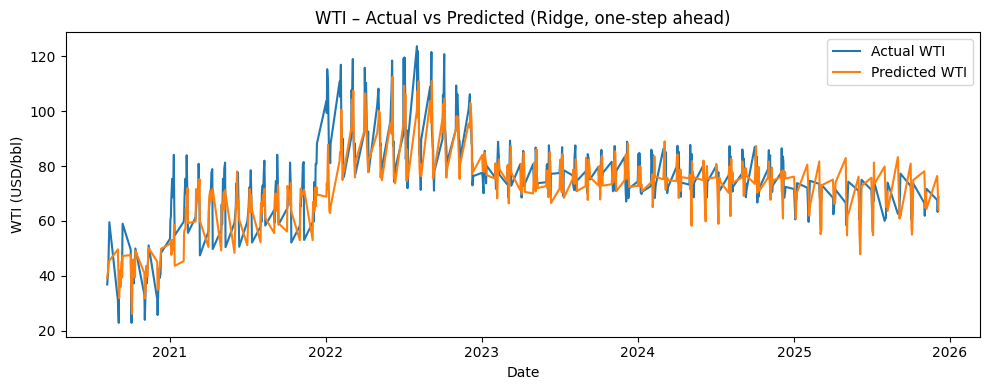

(   Test_MAE  Test_RMSE  Test_MEDIAN_MAPE_%        R2
 0  7.245469   9.624378            7.702771  0.643456,
 '[Download metrics CSV](Metrics/wti_metrics.csv) | [Download predictions CSV](Metrics/wti_predictions.csv)')

In [16]:
pd.DataFrame({"Date": fe['Date'].iloc[split_idx:].values, "WTI_actual": y_test.values, "WTI_pred": pred_test}).to_csv(preds_path, index=False)

plt.figure(figsize=(10,4))
plt.plot(fe['Date'].iloc[split_idx:], y_test.values, label="Actual WTI")
plt.plot(fe['Date'].iloc[split_idx:], pred_test, label="Predicted WTI")
plt.title("WTI – Actual vs Predicted (Ridge, one-step ahead)")
plt.xlabel("Date"); plt.ylabel("WTI (USD/bbl)"); plt.legend(); plt.tight_layout()
plt.show()

metrics, f"[Download metrics CSV]({metrics_path}) | [Download predictions CSV]({preds_path})"